# Анализ игр на платформе Steam

## 1. Описание проекта

В этом проекте я хочу проанализировать игры на платформе Steam и понять, какие факторы могут влиять на их популярность.

Я буду смотреть на такие данные, как цена игры, жанр, дата выхода, количество рекомендаций, разработчик, издатель и поддерживаемые платформы.

In [16]:
import sys
sys.executable

'c:\\Users\\Denry\\steam_capstone\\.venv\\Scripts\\python.exe'

## 2. Импорт библиотек

Сначала импортируем библиотеки, которые понадобятся для работы с данными и построения графиков.

In [17]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

pd.set_option("display.max_columns", None)

## 3. Загрузка данных

На этом этапе загружаем датасет с играми Steam.

Данные были собраны через Steam Store API. В таблице есть информация об играх: название, цена, жанры, дата релиза, рекомендации, разработчики и издатели.

In [18]:
BASE_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()

RAW_DIR = BASE_DIR / "data" / "raw"
PROCESSED_DIR = BASE_DIR / "data" / "processed"
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

INPUT_FILE = RAW_DIR / "steam_games_raw_5000.csv"

df = pd.read_csv(INPUT_FILE)

df.head()

,appid,name,type,is_free,release_date,developers,publishers,genres,categories,platform_windows,platform_mac,platform_linux,required_age,metacritic_score,recommendations,price_currency,initial_price,final_price,discount_percent
0,3057270,Seafarer's Gambit,game,False,"Jul 5, 2024",Bouncy Rocket Studios,Bouncy Rocket Studios,"Action, Adventure, Indie, RPG, Strategy","Single-player, Family Sharing",True,False,False,0,NaN,NaN,NaN,NaN,NaN,NaN
1,3822840,Capitalist Misadventures,game,False,"Jul 25, 2025",Caramelo Studios,Caramelo Studios,"Casual, Indie, Simulation, Strategy","Single-player, Save Anytime, Family Sharing",True,False,False,0,NaN,NaN,USD,799.0,799.0,0.0
2,3216640,The Beast and the Princess,game,False,"Jun 17, 2025",Libragames,Libragames,"Adventure, Indie, Strategy","Single-player, Steam Achievements, Full contro...",True,False,False,0,NaN,NaN,USD,1299.0,1299.0,0.0
3,2403620,Air Twister,game,False,"Nov 10, 2023",YS NET,ININ,"Action, Adventure, Indie","Single-player, Steam Achievements, Full contro...",True,False,False,0,NaN,NaN,USD,2499.0,2499.0,0.0
4,1538040,Horde Slayer,game,False,"Mar 19, 2021",Wagner Rodrigues,Wagner Rodrigues,"Action, Adventure, Casual, Indie, RPG, Early A...","Single-player, Steam Achievements, Full contro...",True,False,True,0,NaN,NaN,USD,399.0,399.0,0.0


## 4. Первичный просмотр данных

Посмотрим, сколько строк и столбцов есть в датасете, какие типы данных используются и где есть пропущенные значения.

In [19]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
df.info()

Rows: 14769
Columns: 19
<class 'pandas.DataFrame'>
RangeIndex: 14769 entries, 0 to 14768
Data columns (total 19 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   appid             14769 non-null  int64  
 1   name              14769 non-null  str    
 2   type              14769 non-null  str    
 3   is_free           14769 non-null  bool   
 4   release_date      14769 non-null  str    
 5   developers        14757 non-null  str    
 6   publishers        14742 non-null  str    
 7   genres            14760 non-null  str    
 8   categories        14768 non-null  str    
 9   platform_windows  14769 non-null  bool   
 10  platform_mac      14769 non-null  bool   
 11  platform_linux    14769 non-null  bool   
 12  required_age      14769 non-null  int64  
 13  metacritic_score  122 non-null    float64
 14  recommendations   1829 non-null   float64
 15  price_currency    12041 non-null  str    
 16  initial_price     12041 non

In [20]:
df.isnull().sum().sort_values(ascending=False)

metacritic_score    14647
recommendations     12940
price_currency       2728
discount_percent     2728
final_price          2728
initial_price        2728
publishers             27
developers             12
genres                  9
categories              1
appid                   0
type                    0
name                    0
release_date            0
is_free                 0
platform_mac            0
platform_windows        0
platform_linux          0
required_age            0
dtype: int64

## 4.1 Описательная статистика

На этом этапе посмотрим основные статистические показатели по числовым признакам: среднее значение, медиану, стандартное отклонение, минимум и максимум.

In [21]:
numeric_summary = df_clean[
    [
        "final_price",
        "initial_price",
        "discount_percent",
        "recommendations",
        "metacritic_score",
        "release_year",
        "game_age",
        "genre_count"
    ]
].describe().T.round(2)

numeric_summary = numeric_summary.rename(columns={
    "count": "Количество",
    "mean": "Среднее",
    "std": "Стандартное отклонение",
    "min": "Минимум",
    "25%": "25%",
    "50%": "Медиана",
    "75%": "75%",
    "max": "Максимум"
})

numeric_summary

,Количество,Среднее,Стандартное отклонение,Минимум,25%,Медиана,75%,Максимум
final_price,14438.0,6.99,12.12,0.0,0.99,4.99,9.99,500.0
initial_price,14438.0,7.64,14.33,0.0,0.99,4.99,9.99,500.0
discount_percent,12041.0,4.64,16.43,0.0,0.00,0.00,0.00,95.0
recommendations,14769.0,373.42,8198.20,0.0,0.00,0.00,0.00,817390.0
metacritic_score,14769.0,0.66,7.29,0.0,0.00,0.00,0.00,94.0
release_year,14507.0,2023.56,1.44,2021.0,2023.00,2024.00,2025.00,2026.0
game_age,14507.0,2.44,1.44,0.0,1.00,2.00,3.00,5.0
genre_count,14769.0,2.89,1.32,0.0,2.00,3.00,4.00,11.0


**Вывод:**  
По описательной статистике видно, что средняя финальная цена игры составляет около 6.99, а медианная цена — 4.99. Это значит, что большинство игр в датасете стоят недорого.

При этом максимальная цена достигает 500, а стандартное отклонение по цене достаточно большое. Это говорит о том, что в данных есть дорогие игры или выбросы, которые сильно отличаются от основной части игр.

Количество рекомендаций тоже распределено очень неравномерно. Среднее значение составляет около 373, но медиана равна 0. Это показывает, что у большинства игр рекомендаций нет или очень мало, а высокое среднее значение появляется из-за отдельных популярных игр с большим количеством рекомендаций.

Средний год релиза — примерно 2024, а большинство игр вышли в период с 2023 по 2025 год. Это говорит о том, что датасет в основном состоит из относительно новых игр.

В среднем у одной игры около 3 жанров. Это показывает, что многие игры относятся сразу к нескольким жанрам.

## 5. Очистка данных

На этом этапе очищаем данные, чтобы дальше с ними было удобнее работать.

Что делаем:
- оставляем только игры;
- удаляем дубликаты;
- убираем строки без названия;
- переводим цену из центов в доллары;
- заполняем некоторые пропущенные значения;
- приводим дату релиза к правильному формату.

In [22]:
df_clean = df.copy()

df_clean = df_clean[df_clean["type"] == "game"]

df_clean = df_clean.drop_duplicates(subset=["appid"])

df_clean = df_clean.dropna(subset=["name"])

df_clean["final_price"] = df_clean["final_price"] / 100
df_clean["initial_price"] = df_clean["initial_price"] / 100

df_clean.loc[df_clean["is_free"] == True, ["final_price", "initial_price"]] = 0

df_clean["recommendations"] = df_clean["recommendations"].fillna(0)
df_clean["metacritic_score"] = df_clean["metacritic_score"].fillna(0)

df_clean.head()

,appid,name,type,is_free,release_date,developers,publishers,genres,categories,platform_windows,platform_mac,platform_linux,required_age,metacritic_score,recommendations,price_currency,initial_price,final_price,discount_percent
0,3057270,Seafarer's Gambit,game,False,"Jul 5, 2024",Bouncy Rocket Studios,Bouncy Rocket Studios,"Action, Adventure, Indie, RPG, Strategy","Single-player, Family Sharing",True,False,False,0,0.0,0.0,NaN,NaN,NaN,NaN
1,3822840,Capitalist Misadventures,game,False,"Jul 25, 2025",Caramelo Studios,Caramelo Studios,"Casual, Indie, Simulation, Strategy","Single-player, Save Anytime, Family Sharing",True,False,False,0,0.0,0.0,USD,7.99,7.99,0.0
2,3216640,The Beast and the Princess,game,False,"Jun 17, 2025",Libragames,Libragames,"Adventure, Indie, Strategy","Single-player, Steam Achievements, Full contro...",True,False,False,0,0.0,0.0,USD,12.99,12.99,0.0
3,2403620,Air Twister,game,False,"Nov 10, 2023",YS NET,ININ,"Action, Adventure, Indie","Single-player, Steam Achievements, Full contro...",True,False,False,0,0.0,0.0,USD,24.99,24.99,0.0
4,1538040,Horde Slayer,game,False,"Mar 19, 2021",Wagner Rodrigues,Wagner Rodrigues,"Action, Adventure, Casual, Indie, RPG, Early A...","Single-player, Steam Achievements, Full contro...",True,False,True,0,0.0,0.0,USD,3.99,3.99,0.0


In [23]:
df_clean["release_date"] = pd.to_datetime(df_clean["release_date"], errors="coerce")

df_clean["release_year"] = df_clean["release_date"].dt.year

df_clean["game_age"] = 2026 - df_clean["release_year"]

df_clean["genre_count"] = df_clean["genres"].fillna("").apply(
    lambda x: len(x.split(",")) if x else 0
)

df_clean.head()

,appid,name,type,is_free,release_date,developers,publishers,genres,categories,platform_windows,platform_mac,platform_linux,required_age,metacritic_score,recommendations,price_currency,initial_price,final_price,discount_percent,release_year,game_age,genre_count
0,3057270,Seafarer's Gambit,game,False,2024-07-05,Bouncy Rocket Studios,Bouncy Rocket Studios,"Action, Adventure, Indie, RPG, Strategy","Single-player, Family Sharing",True,False,False,0,0.0,0.0,NaN,NaN,NaN,NaN,2024.0,2.0,5
1,3822840,Capitalist Misadventures,game,False,2025-07-25,Caramelo Studios,Caramelo Studios,"Casual, Indie, Simulation, Strategy","Single-player, Save Anytime, Family Sharing",True,False,False,0,0.0,0.0,USD,7.99,7.99,0.0,2025.0,1.0,4
2,3216640,The Beast and the Princess,game,False,2025-06-17,Libragames,Libragames,"Adventure, Indie, Strategy","Single-player, Steam Achievements, Full contro...",True,False,False,0,0.0,0.0,USD,12.99,12.99,0.0,2025.0,1.0,3
3,2403620,Air Twister,game,False,2023-11-10,YS NET,ININ,"Action, Adventure, Indie","Single-player, Steam Achievements, Full contro...",True,False,False,0,0.0,0.0,USD,24.99,24.99,0.0,2023.0,3.0,3
4,1538040,Horde Slayer,game,False,2021-03-19,Wagner Rodrigues,Wagner Rodrigues,"Action, Adventure, Casual, Indie, RPG, Early A...","Single-player, Steam Achievements, Full contro...",True,False,True,0,0.0,0.0,USD,3.99,3.99,0.0,2021.0,5.0,6


## 6. Создание новых признаков

Добавим несколько новых признаков, которые помогут в анализе.

Например:
- год выхода игры;
- возраст игры;
- количество жанров;
- категория цены.

In [24]:
def price_category(price):
    if price == 0:
        return "Free"
    elif price <= 10:
        return "Low"
    elif price <= 30:
        return "Medium"
    else:
        return "High"

df_clean["price_category"] = df_clean["final_price"].fillna(0).apply(price_category)

df_clean[["name", "final_price", "price_category"]].head()

,name,final_price,price_category
0,Seafarer's Gambit,NaN,Free
1,Capitalist Misadventures,7.99,Low
2,The Beast and the Princess,12.99,Medium
3,Air Twister,24.99,Medium
4,Horde Slayer,3.99,Low


## 7. Сохранение очищенного датасета

После очистки сохраним новый датасет в отдельный файл, чтобы потом использовать его для анализа, SQL-запросов и dashboard.

In [25]:
OUTPUT_FILE = PROCESSED_DIR / "steam_games_cleaned.csv"

df_clean.to_csv(OUTPUT_FILE, index=False)

print("Saved to:", OUTPUT_FILE)
print("Final shape:", df_clean.shape)

Saved to: c:\Users\Denry\steam_capstone\data\processed\steam_games_cleaned.csv
Final shape: (14769, 23)


## 8. EDA

Теперь посмотрим на данные через графики и попробуем найти интересные закономерности.

In [26]:
df_clean.describe()

,appid,release_date,required_age,metacritic_score,recommendations,initial_price,final_price,discount_percent,release_year,game_age,genre_count
count,1.476900e+04,14507,14769.000000,14769.000000,14769.000000,14438.000000,14438.000000,12041.000000,14507.000000,14507.000000,14769.000000
mean,2.655751e+06,2024-01-28 16:33:31.056731,0.069808,0.660979,373.419934,7.642614,6.994860,4.635080,2023.557041,2.442959,2.889905
min,1.200570e+06,2021-01-01 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2021.000000,0.000000,0.000000
25%,1.996430e+06,2023-02-01 00:00:00,0.000000,0.000000,0.000000,0.990000,0.990000,0.000000,2023.000000,1.000000,2.000000
50%,2.568810e+06,2024-06-26 00:00:00,0.000000,0.000000,0.000000,4.990000,4.990000,0.000000,2024.000000,2.000000,3.000000
75%,3.374950e+06,2025-04-30 00:00:00,0.000000,0.000000,0.000000,9.990000,9.990000,0.000000,2025.000000,3.000000,4.000000
max,4.243930e+06,2026-05-23 00:00:00,21.000000,94.000000,817390.000000,500.000000,500.000000,95.000000,2026.000000,5.000000,11.000000
std,7.788851e+05,NaN,1.082806,7.292273,8198.196459,14.333225,12.116842,16.428822,1.436403,1.436403,1.324129


### 8.1 Распределение цен

Посмотрим, какие цены чаще всего встречаются у игр в Steam.

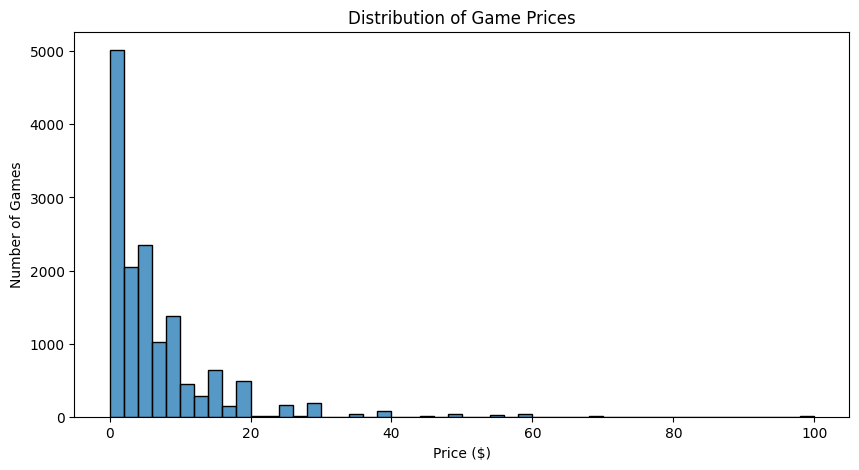

In [27]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean[df_clean["final_price"] <= 100]["final_price"], bins=50)
plt.title("Distribution of Game Prices")
plt.xlabel("Price ($)")
plt.ylabel("Number of Games")
plt.show()

**Вывод:**  
Большинство игр имеют невысокую цену. Также видно, что дорогих игр намного меньше, чем игр в низком и среднем ценовом диапазоне.

### 8.2 Игры по ценовым категориям

Разделим игры на категории по цене и посмотрим, каких игр больше: бесплатных, дешёвых, средних или дорогих.

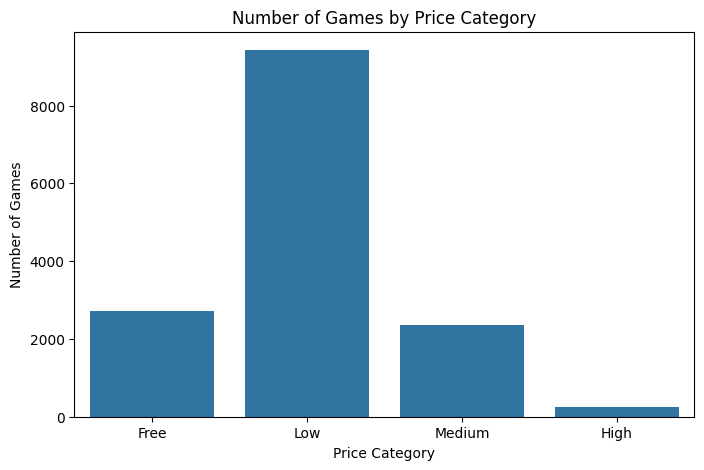

In [28]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="price_category", order=["Free", "Low", "Medium", "High"])
plt.title("Number of Games by Price Category")
plt.xlabel("Price Category")
plt.ylabel("Number of Games")
plt.show()

**Вывод:**  
В датасете больше всего игр из низкой и средней ценовой категории. Бесплатные игры тоже есть, но их меньше по сравнению с платными.

### 8.3 Количество игр по годам

Посмотрим, как менялось количество выпущенных игр на Steam по годам.

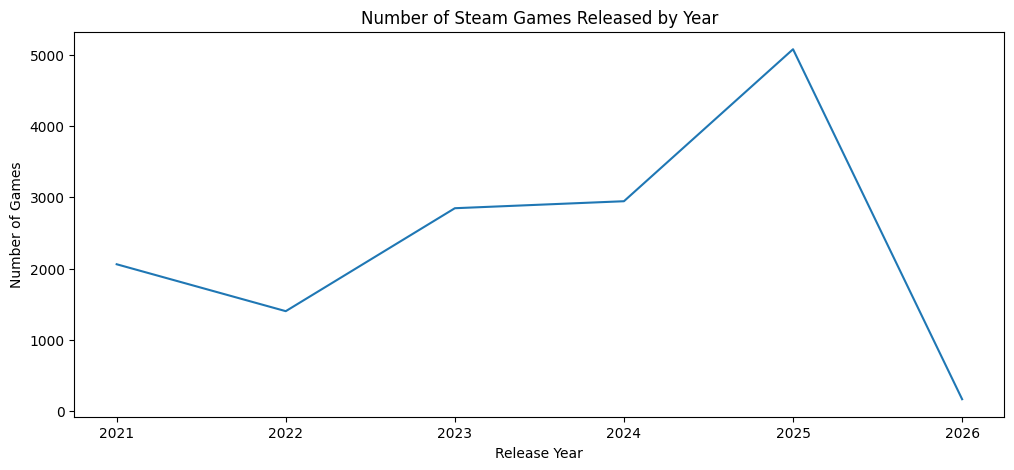

In [29]:
games_by_year = df_clean["release_year"].value_counts().sort_index()

plt.figure(figsize=(12, 5))
games_by_year.plot(kind="line")
plt.title("Number of Steam Games Released by Year")
plt.xlabel("Release Year")
plt.ylabel("Number of Games")
plt.show()

**Вывод:**  
По графику видно, что количество игр в датасете в целом растёт с 2021 по 2025 год. Особенно заметный рост наблюдается в 2025 году — в этот период в данных больше всего релизов.

В 2022 году видно небольшое снижение по сравнению с 2021 годом, но после этого количество игр снова начинает увеличиваться.

Значение за 2026 год почти отсутствует, потому что данные за этот год, скорее всего, неполные. Поэтому 2026 год лучше не учитывать при основных выводах.

### 8.4 Самые частые жанры

Посмотрим, какие жанры чаще всего встречаются среди игр.

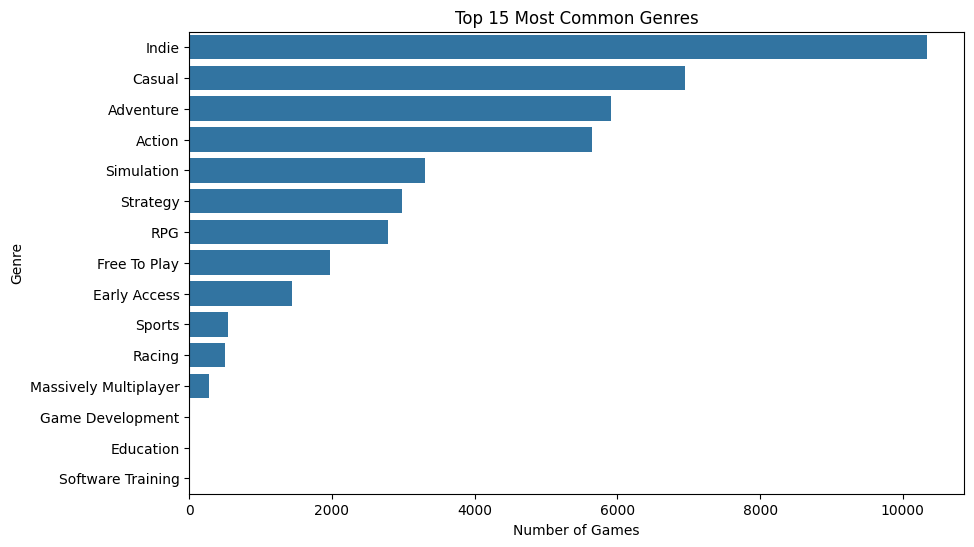

In [30]:
genres_series = df_clean["genres"].dropna().str.split(", ").explode()

top_genres = genres_series.value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 15 Most Common Genres")
plt.xlabel("Number of Games")
plt.ylabel("Genre")
plt.show()

**Вывод:**  
По графику видно, что самым частым жанром в датасете является `Indie`. Это может быть связано с тем, что на Steam много независимых разработчиков и небольших студий, которым проще публиковать свои игры на платформе.

Также часто встречаются жанры `Casual`, `Adventure` и `Action`. Эти жанры довольно массовые и подходят для широкой аудитории.

Жанры вроде `Sports`, `Racing`, `Massively Multiplayer` и `Game Development` встречаются заметно реже. Это показывает, что структура игр на Steam сильно смещена в сторону инди, казуальных и приключенческих проектов.

### 8.5 Бесплатные и платные игры

Сравним количество бесплатных и платных игр в датасете.

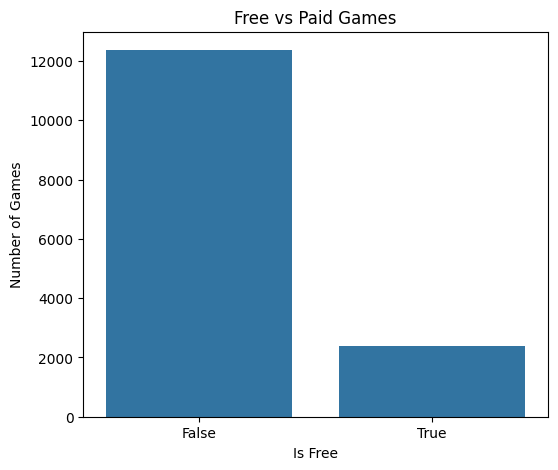

In [31]:
plt.figure(figsize=(6, 5))
sns.countplot(data=df_clean, x="is_free")
plt.title("Free vs Paid Games")
plt.xlabel("Is Free")
plt.ylabel("Number of Games")
plt.show()

**Вывод:**  
Платных игр в датасете значительно больше, чем бесплатных. Это значит, что основная часть игр на Steam распространяется по платной модели.

### 8.6 Рекомендации по ценовым категориям

Посмотрим, как количество рекомендаций отличается у игр из разных ценовых категорий.

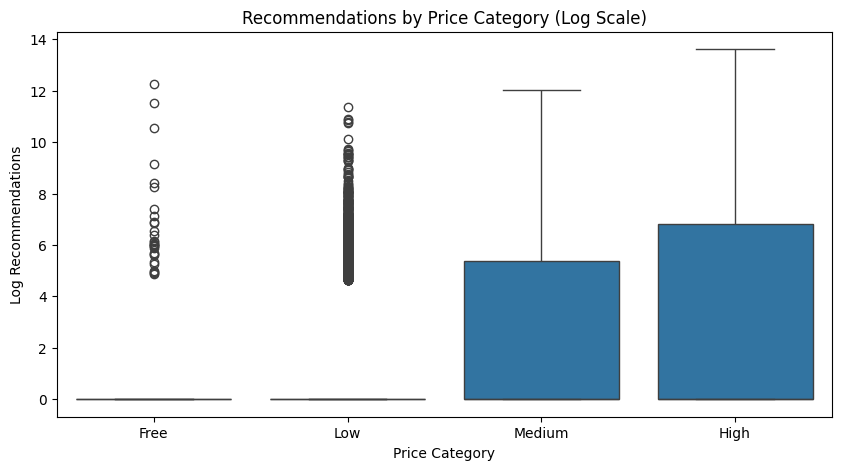

In [32]:
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=df_clean,
    x="price_category",
    y=np.log1p(df_clean["recommendations"]),
    order=["Free", "Low", "Medium", "High"]
)

plt.title("Recommendations by Price Category (Log Scale)")
plt.xlabel("Price Category")
plt.ylabel("Log Recommendations")
plt.show()

**Вывод:**  
После применения логарифмической шкалы график стал более понятным, потому что количество рекомендаций распределено очень неравномерно.

Видно, что у большинства игр во всех ценовых категориях рекомендаций немного. При этом в каждой категории есть отдельные игры, которые получают намного больше рекомендаций.

Категории `Medium` и `High` имеют более широкий разброс значений, то есть среди средних и дорогих игр чаще встречаются проекты с большим количеством рекомендаций. Но при этом дешёвые и бесплатные игры тоже могут получать много рекомендаций.

Можно сделать вывод, что цена сама по себе не определяет популярность игры. На количество рекомендаций, скорее всего, влияют и другие факторы: жанр, качество игры, известность разработчика, маркетинг и интерес игроков.

### 8.7 Корреляция между признаками

Построим тепловую карту, чтобы посмотреть, есть ли связь между числовыми признаками.

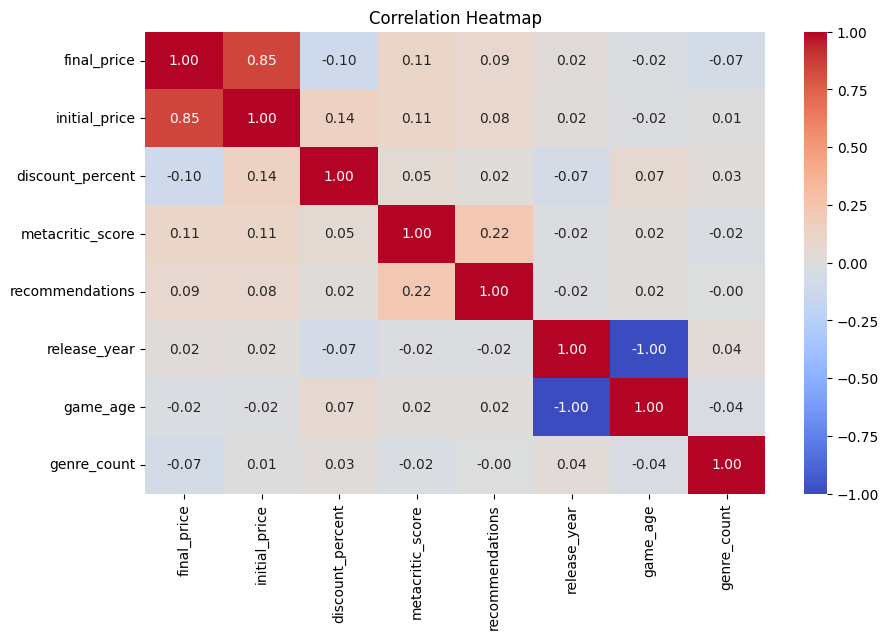

In [33]:
numeric_cols = [
    "final_price",
    "initial_price",
    "discount_percent",
    "metacritic_score",
    "recommendations",
    "release_year",
    "game_age",
    "genre_count"
]

corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

**Вывод:**  
По корреляционной матрице видно, что самая сильная связь наблюдается между `initial_price` и `final_price` — это логично, потому что финальная цена напрямую зависит от начальной цены.

Также видно, что `release_year` и `game_age` имеют почти идеальную отрицательную корреляцию. Это тоже ожидаемо: чем новее год релиза, тем меньше возраст игры.

Связь между `recommendations` и другими признаками слабая. Это означает, что количество рекомендаций не зависит только от цены, года релиза или количества жанров. Скорее всего, популярность игры формируется сразу несколькими факторами: качеством игры, жанром, маркетингом, известностью разработчика и отзывами игроков.

В целом, по этой матрице можно сделать вывод, что одного числового признака недостаточно, чтобы объяснить успешность игры.

### 8.8 Топ разработчиков по количеству игр

Посмотрим, какие разработчики чаще всего встречаются в датасете.

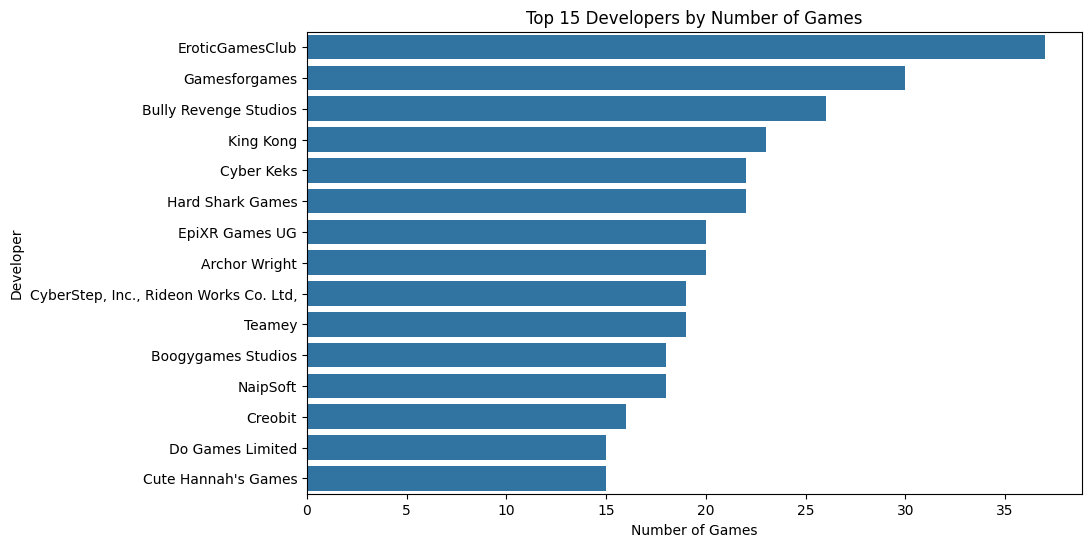

In [34]:
top_developers = df_clean["developers"].dropna().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_developers.values, y=top_developers.index)
plt.title("Top 15 Developers by Number of Games")
plt.xlabel("Number of Games")
plt.ylabel("Developer")
plt.show()

**Вывод:**  
На графике видно, какие разработчики чаще всего встречаются в датасете. Больше всего игр у `EroticGamesClub`, `Gamesforgames` и `Bully Revenge Studios`.

При этом стоит учитывать, что большое количество игр не всегда означает высокую популярность или качество. Некоторые разработчики могут выпускать много небольших проектов, поэтому дальше полезно сравнить не только количество игр, но и рекомендации пользователей.

Этот график помогает понять, какие студии наиболее активно публикуют игры на Steam в рамках нашего датасета.

### 8.9 Топ издателей по количеству игр

Посмотрим, какие издатели чаще всего публикуют игры на платформе Steam.

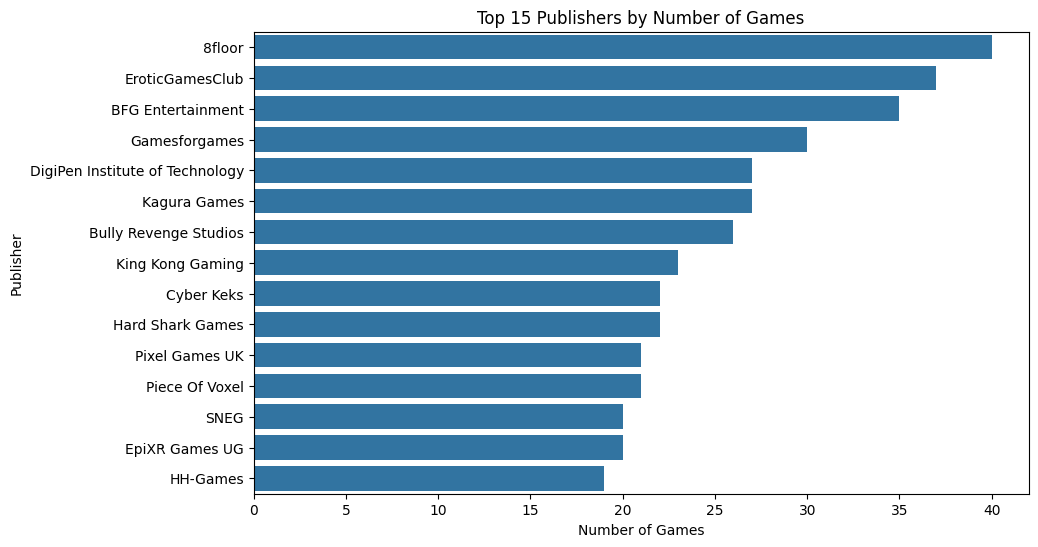

In [35]:
top_publishers = df_clean["publishers"].dropna().value_counts().head(15)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_publishers.values, y=top_publishers.index)
plt.title("Top 15 Publishers by Number of Games")
plt.xlabel("Number of Games")
plt.ylabel("Publisher")
plt.show()

**Вывод:**  
На графике показаны издатели, которые чаще всего встречаются в датасете. Больше всего игр опубликовано издателями `8floor`, `EroticGamesClub` и `BFG Entertainment`.

Как и в случае с разработчиками, большое количество опубликованных игр не всегда означает высокую популярность. Некоторые издатели могут выпускать много небольших или нишевых проектов.

Этот график помогает увидеть, какие издатели наиболее активно публикуют игры на Steam. Для более точного анализа дальше можно сравнить издателей не только по количеству игр, но и по количеству рекомендаций.

### 8.10 Поддерживаемые платформы

Посмотрим, какие платформы чаще всего поддерживаются играми: Windows, Mac и Linux.

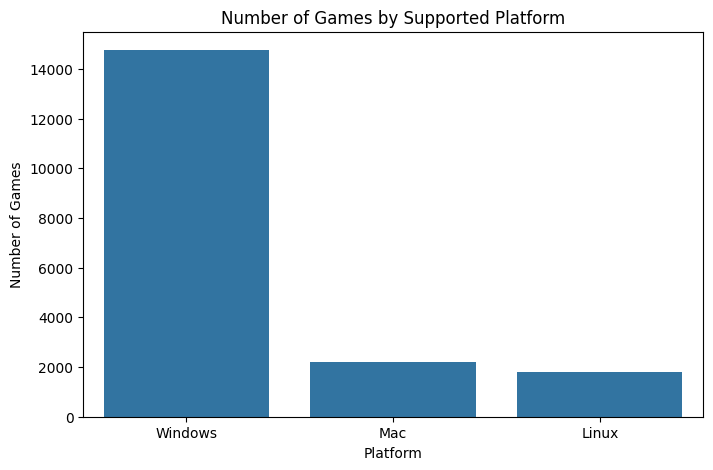

In [36]:
platform_counts = {
    "Windows": df_clean["platform_windows"].sum(),
    "Mac": df_clean["platform_mac"].sum(),
    "Linux": df_clean["platform_linux"].sum()
}

platform_df = pd.DataFrame(
    list(platform_counts.items()),
    columns=["Platform", "Number of Games"]
)

plt.figure(figsize=(8, 5))
sns.barplot(data=platform_df, x="Platform", y="Number of Games")
plt.title("Number of Games by Supported Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Games")
plt.show()

**Вывод:**  
Большинство игр поддерживают Windows, так как это основная платформа для PC-гейминга.  
Mac и Linux встречаются реже, что показывает меньшую поддержку этих систем среди игр Steam.

### 8.11 Топ игр по количеству рекомендаций

Посмотрим, какие игры имеют самое большое количество рекомендаций пользователей.

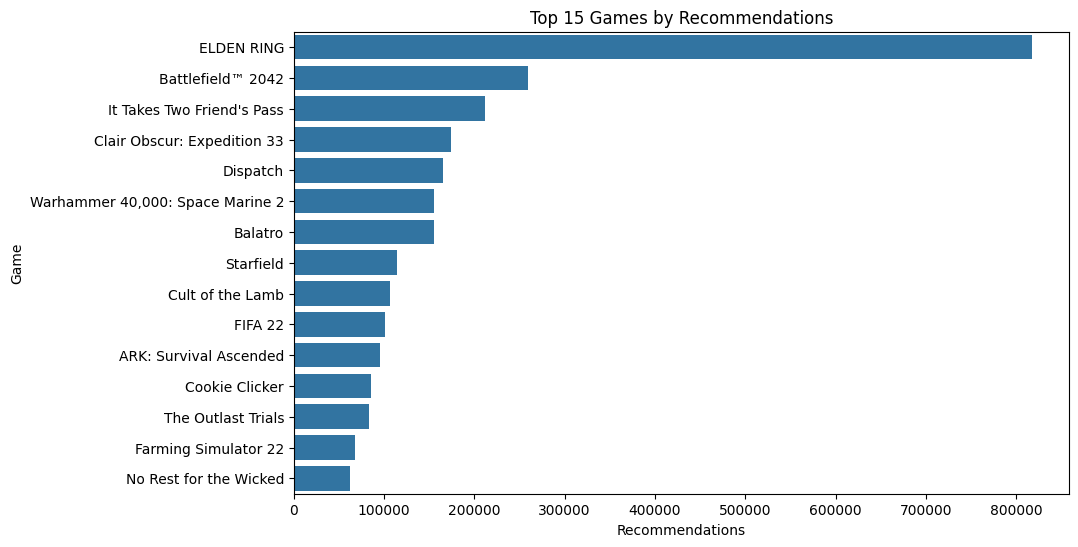

In [37]:
top_recommended_games = df_clean.sort_values(
    by="recommendations",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_recommended_games,
    x="recommendations",
    y="name"
)

plt.title("Top 15 Games by Recommendations")
plt.xlabel("Recommendations")
plt.ylabel("Game")
plt.show()

**Вывод:**  
На графике видно, что больше всего рекомендаций имеет `ELDEN RING`. Она сильно выделяется на фоне остальных игр, что показывает её очень высокую популярность среди пользователей Steam.

Также в топ входят такие игры, как `Battlefield™ 2042`, `It Takes Two Friend's Pass`, `Clair Obscur: Expedition 33`, `Dispatch` и другие. Это показывает, что большое количество рекомендаций чаще получают известные или активно обсуждаемые проекты.

При этом разница между первым местом и остальными играми очень большая. Это говорит о том, что распределение рекомендаций неравномерное: небольшое количество игр получает основную часть внимания пользователей.

## 9. Итоговые выводы по EDA

После первичного анализа датасета Steam можно сделать несколько выводов.

Во-первых, большинство игр в датасете имеют низкую или среднюю цену. Бесплатные игры тоже есть, но основная часть игр всё-таки является платной.

Во-вторых, количество релизов игр на Steam в целом увеличивалось с 2021 по 2025 год. Это показывает, что платформа продолжает активно развиваться, и каждый год появляется много новых игр. При этом 2026 год лучше не учитывать в основных выводах, потому что данные за этот год неполные.

Также видно, что самые частые жанры — это Indie, Casual, Adventure и Action. Это говорит о том, что на Steam очень много инди-игр и проектов для широкой аудитории.

Анализ разработчиков и издателей показал, что некоторые студии и издатели выпускают намного больше игр, чем остальные. Но большое количество игр не всегда означает высокую популярность, поэтому важно смотреть не только на количество проектов, но и на рекомендации пользователей.

По графикам рекомендаций видно, что распределение очень неравномерное. У большинства игр рекомендаций немного, но есть отдельные игры, которые получают очень большое количество рекомендаций. Например, в датасете сильно выделяется ELDEN RING.

Корреляционный анализ показал, что цена, год релиза и количество жанров не имеют сильной прямой связи с количеством рекомендаций. Это значит, что популярность игры нельзя объяснить только одним фактором. Скорее всего, на неё влияют сразу несколько вещей: жанр, качество игры, известность разработчика, маркетинг, отзывы игроков и интерес аудитории.

В целом, EDA помог лучше понять структуру датасета и увидеть основные закономерности. Дальше эти данные можно использовать для SQL-анализа и создания dashboard в Power BI.